In [1]:
"""
===================================================================
ESTIMACIÓN DE ÉXITO OFENSIVO
LSTM/GRU + Métricas de Grafo - Análisis Táctico
===================================================================
"""

import sys
import os

notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from src.data.loader import StatsBombLoader
from src.data.preprocessing import PassPreprocessor
from src.graphs.pass_graph import PassGraph
from src.graphs.network_metrics import NetworkMetrics
from src.graphs.dynamic_graph import DynamicPassGraph
from src.models.sequential import SequentialTacticalModel
from src.models.evaluation import ModelEvaluator

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Librerías cargadas")
print("\n" + "="*70)
print("🎯 ESTIMACIÓN DE ÉXITO OFENSIVO")
print("   LSTM/GRU + Métricas de Grafo")
print("="*70)

✅ TensorFlow cargado: 2.21.0
✅ Librerías cargadas

🎯 ESTIMACIÓN DE ÉXITO OFENSIVO
   LSTM/GRU + Métricas de Grafo


In [2]:
# ===================================================================
# CARGA DE DATOS Y CONSTRUCCIÓN DE FEATURES COMBINADAS
# ===================================================================

print("\n📊 CARGANDO DATOS...")
print("="*70)

loader = StatsBombLoader()
preprocessor = PassPreprocessor()

SEASONS = [
    {'season_id': 90, 'season_name': '2020/2021'},
    {'season_id': 42, 'season_name': '2019/2020'},
    {'season_id': 4,  'season_name': '2018/2019'},
]

COMPETITION_ID = 11

# Almacenar datos por partido
match_records = []

for season in SEASONS:
    print(f"\n⚽ Procesando temporada {season['season_name']}...")

    matches = loader.get_matches(
        competition_id=COMPETITION_ID,
        season_id=season['season_id']
    )

    barca_matches = matches[
        (matches['home_team'] == 'Barcelona') |
        (matches['away_team'] == 'Barcelona')
    ]

    for _, match_row in barca_matches.iterrows():
        match_id = match_row['match_id']

        try:
            # Cargar eventos
            events, _ = loader.load_match_data(match_id)

            # Preprocesar pases
            passes_clean = preprocessor.preprocess_full_pipeline(
                events, team_name='Barcelona'
            )

            if len(passes_clean) < 10:
                continue

            # ── Métricas de grafo ──────────────────────────────────
            pass_graph = PassGraph(weight_type='frequency')
            G = pass_graph.build_graph(passes_clean, team='Barcelona')

            metrics_calc = NetworkMetrics(G)
            metrics_calc.calculate_all_metrics()

            graph_metrics = {
                'density':         metrics_calc.metrics['density'],
                'avg_clustering':  np.mean(list(metrics_calc.metrics['clustering'].values())),
                'avg_betweenness': np.mean(list(metrics_calc.metrics['centrality']['betweenness'].values())),
                'avg_pagerank':    np.mean(list(metrics_calc.metrics['centrality']['pagerank'].values())),
                'avg_closeness':   np.mean(list(metrics_calc.metrics['centrality']['closeness'].values())),
                'num_nodes':       G.number_of_nodes(),
                'num_edges':       G.number_of_edges(),
            }

            # ── xG real como target ────────────────────────────────
            shots = events[
                (events['type'] == 'Shot') &
                (events['team'] == 'Barcelona')
            ]
            xg_total = 0.0
            if 'shot_statsbomb_xg' in shots.columns:
                xg_total = shots['shot_statsbomb_xg'].sum()

            # ── Secuencias de eventos ofensivos ────────────────────
            offensive_events = events[
                (events['team'] == 'Barcelona') &
                (events['type'].isin([
                    'Pass', 'Carry', 'Dribble', 'Shot', 'Ball Receipt*'
                ]))
            ].reset_index(drop=True)

            match_records.append({
                'match_id':         match_id,
                'season':           season['season_name'],
                'events':           offensive_events,
                'graph_metrics':    graph_metrics,
                'xg_total':         xg_total,
                'total_passes':     len(passes_clean),
                'pass_accuracy':    passes_clean['pass_success'].mean() if 'pass_success' in passes_clean.columns else 0.0,
            })

        except Exception as e:
            print(f"   ⚠️  Error partido {match_id}: {e}")

print(f"\n{'='*70}")
print(f"✅ Partidos procesados: {len(match_records)}")
print(f"{'='*70}")


📊 CARGANDO DATOS...
📁 Data directory: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw

⚽ Procesando temporada 2020/2021...
✅ Partidos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\matches_11_90.csv
✅ Eventos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\events_3773386.csv
📊 Partido 3773386:
   - Total eventos: 3891
   - Total pases: 1118

🧹 INICIANDO PIPELINE DE PREPROCESAMIENTO

📊 Eventos totales: 3891
✅ Pases encontrados: 1118
🧹 Pases después de eliminar nulos en player/team: 1118
✅ Precisión de pase: 83.90%
🧹 Pases después de filtrar por distancia: 1118 (eliminados: 0)
✅ Normalización temporal completada
🧹 Pases con receptor válido: 1060 (eliminados: 58)
🎯 Pases de Barcelona: 850

✅ PREPROCESAMIENTO COMPLETADO: 850 pases válidos


🔨 Construyendo grafo de pases (peso: frequency)...
   Filtrando equipo: Barcelona
✅ Grafo construido:
   - Nodos (jugadores): 16
   - Aristas (conexiones): 152

🔬 CAL

In [3]:
# ===================================================================
# CONSTRUCCIÓN DE SECUENCIAS + MÉTRICAS DE GRAFO
# ===================================================================

print("\n🔨 CONSTRUYENDO SECUENCIAS CON MÉTRICAS DE GRAFO...")
print("="*70)

SEQ_LEN = 8

def extract_offensive_features(event_row):
    features = {}
    features['minute']   = event_row.get('minute', 0)
    features['period']   = event_row.get('period', 1)
    event_types = {
        'Pass': 1, 'Carry': 2, 'Dribble': 3,
        'Shot': 4, 'Ball Receipt*': 5, 'Other': 0
    }
    features['event_type'] = event_types.get(event_row.get('type', 'Other'), 0)
    location = event_row.get('location', None)
    if isinstance(location, list) and len(location) == 2:
        features['loc_x']       = location[0]
        features['loc_y']       = location[1]
        features['dist_goal']   = np.sqrt((location[0]-120)**2 + (location[1]-40)**2)
        features['zona_ataque'] = 1 if location[0] > 80 else 0
    else:
        features['loc_x']       = 60.0
        features['loc_y']       = 40.0
        features['dist_goal']   = 60.0
        features['zona_ataque'] = 0
    if event_row.get('type') == 'Pass':
        features['pass_success'] = 1 if pd.isna(event_row.get('pass_outcome')) else 0
    else:
        features['pass_success'] = 0
    return features

X_seq_combined = []
y_xg           = []

for record in match_records:
    events_df = record['events'].reset_index(drop=True)
    graph_m   = record['graph_metrics']

    if len(events_df) < SEQ_LEN + 1:
        continue

    # Vector de métricas de grafo
    graph_vector = np.array([
        graph_m['density'],
        graph_m['avg_clustering'],
        graph_m['avg_betweenness'],
        graph_m['avg_pagerank'],
        graph_m['avg_closeness'],
        graph_m['num_nodes']  / 20.0,
        graph_m['num_edges']  / 200.0,
    ])

    # Extraer features de eventos
    event_features = []
    for _, row in events_df.iterrows():
        feat = extract_offensive_features(row)
        event_features.append(feat)

    df_feat  = pd.DataFrame(event_features).fillna(0)
    X_events = df_feat.values

    # ── Target: xG del siguiente tiro tras la secuencia ──────────
    for i in range(len(X_events) - SEQ_LEN):
        seq = X_events[i:i + SEQ_LEN]

        # Buscar el siguiente tiro después de la secuencia
        next_events = events_df.iloc[i + SEQ_LEN:]
        next_shots  = next_events[next_events['type'] == 'Shot']

        if len(next_shots) > 0 and 'shot_statsbomb_xg' in next_shots.columns:
            xg_next = next_shots.iloc[0]['shot_statsbomb_xg']
            xg_next = xg_next if not pd.isna(xg_next) else 0.0
        else:
            xg_next = 0.0

        # Concatenar métricas de grafo a cada paso temporal
        graph_repeated = np.tile(graph_vector, (SEQ_LEN, 1))
        seq_combined   = np.concatenate([seq, graph_repeated], axis=1)

        X_seq_combined.append(seq_combined)
        y_xg.append(xg_next)

X_combined = np.array(X_seq_combined)
y_combined = np.array(y_xg)

print(f"\n✅ SECUENCIAS CONSTRUIDAS:")
print(f"   - Total secuencias:  {len(X_combined)}")
print(f"   - Shape:             {X_combined.shape}")
print(f"   - Features totales:  {X_combined.shape[2]}")
print(f"     → Eventos:         {df_feat.shape[1]}")
print(f"     → Grafo:           {len(graph_vector)}")
print(f"   - xG medio:          {y_combined.mean():.4f}")
print(f"   - xG > 0:            {(y_combined > 0).sum()} secuencias ({(y_combined>0).mean()*100:.1f}%)")
print(f"   - xG rango:          [{y_combined.min():.3f}, {y_combined.max():.3f}]")


🔨 CONSTRUYENDO SECUENCIAS CON MÉTRICAS DE GRAFO...

✅ SECUENCIAS CONSTRUIDAS:
   - Total secuencias:  214115
   - Shape:             (214115, 8, 15)
   - Features totales:  15
     → Eventos:         8
     → Grafo:           7
   - xG medio:          0.1102
   - xG > 0:            213545 secuencias (99.7%)
   - xG rango:          [0.000, 0.953]


In [4]:
# ===================================================================
# SPLIT Y ESCALADO
# ===================================================================

print("\n🔧 PREPARANDO DATOS...")

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_combined,
    test_size=0.25,
    random_state=42
)

n_train, seq_len, n_features = X_train.shape

scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

X_train_sc = scaler.fit_transform(X_train_2d).reshape(
    n_train, seq_len, n_features
)
X_test_sc = scaler.transform(X_test_2d).reshape(
    X_test.shape[0], seq_len, n_features
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sc, y_train,
    test_size=0.2,
    random_state=42
)

print(f"✅ Datos preparados:")
print(f"   - Train:      {X_tr.shape[0]} secuencias")
print(f"   - Validación: {X_val.shape[0]} secuencias")
print(f"   - Test:       {X_test_sc.shape[0]} secuencias")
print(f"   - Features:   {n_features} (eventos + grafo)")


🔧 PREPARANDO DATOS...
✅ Datos preparados:
   - Train:      128468 secuencias
   - Validación: 32118 secuencias
   - Test:       53529 secuencias
   - Features:   15 (eventos + grafo)


In [5]:
# ===================================================================
# REDUCIR DATASET PARA ACELERAR ENTRENAMIENTO
# ===================================================================

MAX_SAMPLES = 20000  # Máximo de secuencias a usar

if len(X_combined) > MAX_SAMPLES:
    idx = np.random.choice(len(X_combined), MAX_SAMPLES, replace=False)
    X_combined = X_combined[idx]
    y_combined = y_combined[idx]
    print(f"✅ Dataset reducido a {MAX_SAMPLES} secuencias para entrenamiento")
else:
    print(f"✅ Dataset completo: {len(X_combined)} secuencias")

✅ Dataset reducido a 20000 secuencias para entrenamiento



🔬 COMPARATIVA DE MODELOS - ESTIMACIÓN xG

🔧 Entrenando LSTM + Grafo...

🔧 Entrenando LSTM (regression)...
   - Input shape: (128468, 8, 15)
   - Epochs: 15 | Batch: 64

✅ Modelo LSTM construido:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 8, 32)               │           6,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 8, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 8, 32)               │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,049 (39.25 KB)

 Trainable params: 9,953 (38.88 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 52s 20ms/step - loss: 0.0297 - mae: 0.1128 - val_loss: 0.0097 - val_mae: 0.0682 - learning_rate: 0.0010
Epoch 2/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - loss: 0.0089 - mae: 0.0661 - val_loss: 0.0032 - val_mae: 0.0403 - learning_rate: 0.0010
Epoch 3/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - loss: 0.0038 - mae: 0.0429 - val_loss: 0.0014 - val_mae: 0.0267 - learning_rate: 0.0010
Epoch 4/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - loss: 0.0023 - mae: 0.0335 - val_loss: 9.5372e-04 - val_mae: 0.0198 - learning_rate: 0.0010
Epoch 5/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - loss: 0.0018 - mae: 0.0281 - val_loss: 7.8151e-04 - val_mae: 0.0173 - learning_rate: 0.0010
Epoch 6/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - loss: 0.0014 - mae: 0.0240 - val_loss: 6.5197e-04 - val_mae: 0.0146 - learning_rate: 0.0010
Epoch 7/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - loss: 0.0012 - mae: 0.0215 - val_loss: 5.6040e-04 - va

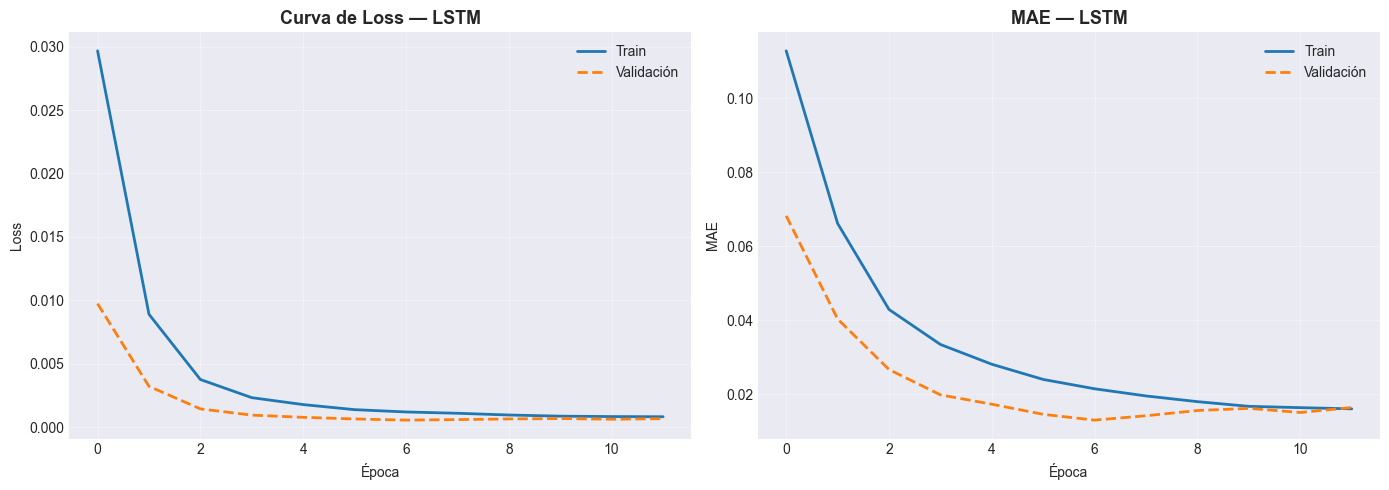


🔧 Entrenando GRU + Grafo...

🔧 Entrenando GRU (regression)...
   - Input shape: (128468, 8, 15)
   - Epochs: 15 | Batch: 64

✅ Modelo GRU construido:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 8, 32)               │           4,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 8, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 8, 32)               │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 16)                  │           2,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,777 (30.38 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 54s 21ms/step - loss: 0.0247 - mae: 0.1060 - val_loss: 0.0106 - val_mae: 0.0678 - learning_rate: 0.0010
Epoch 2/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - loss: 0.0094 - mae: 0.0651 - val_loss: 0.0057 - val_mae: 0.0449 - learning_rate: 0.0010
Epoch 3/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 0.0041 - mae: 0.0441 - val_loss: 0.0017 - val_mae: 0.0295 - learning_rate: 0.0010
Epoch 4/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 0.0024 - mae: 0.0339 - val_loss: 0.0010 - val_mae: 0.0226 - learning_rate: 0.0010
Epoch 5/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 0.0017 - mae: 0.0284 - val_loss: 9.4551e-04 - val_mae: 0.0215 - learning_rate: 0.0010
Epoch 6/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - loss: 0.0014 - mae: 0.0251 - val_loss: 7.4642e-04 - val_mae: 0.0165 - learning_rate: 0.0010
Epoch 7/15
2008/2008 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - loss: 0.0013 - mae: 0.0231 - val_loss: 6.5379e-04 - val_ma

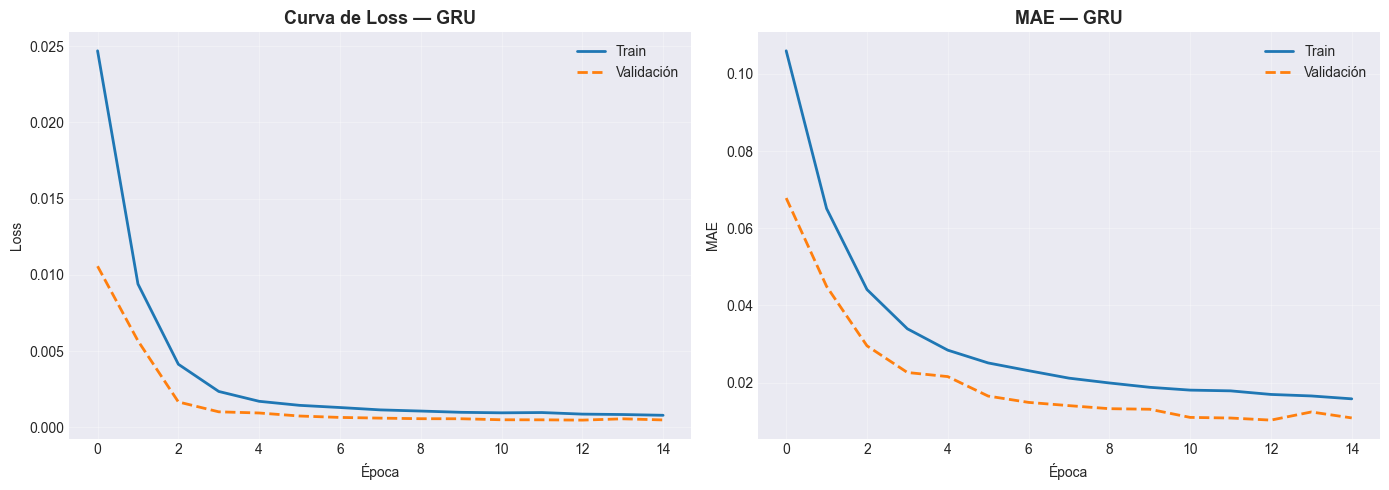


🔧 Entrenando Random Forest baseline...
   ✅ RF Baseline → MAE: 0.0019 | RMSE: 0.0171 | R²: 0.9791


📊 TABLA COMPARATIVA


,Modelo,MAE,RMSE,R² (Test)
0,Random Forest (baseline),0.0019,0.0171,0.9791
1,GRU + Grafo,0.0101,0.0200,0.9716
2,LSTM + Grafo,0.0129,0.0220,0.9656


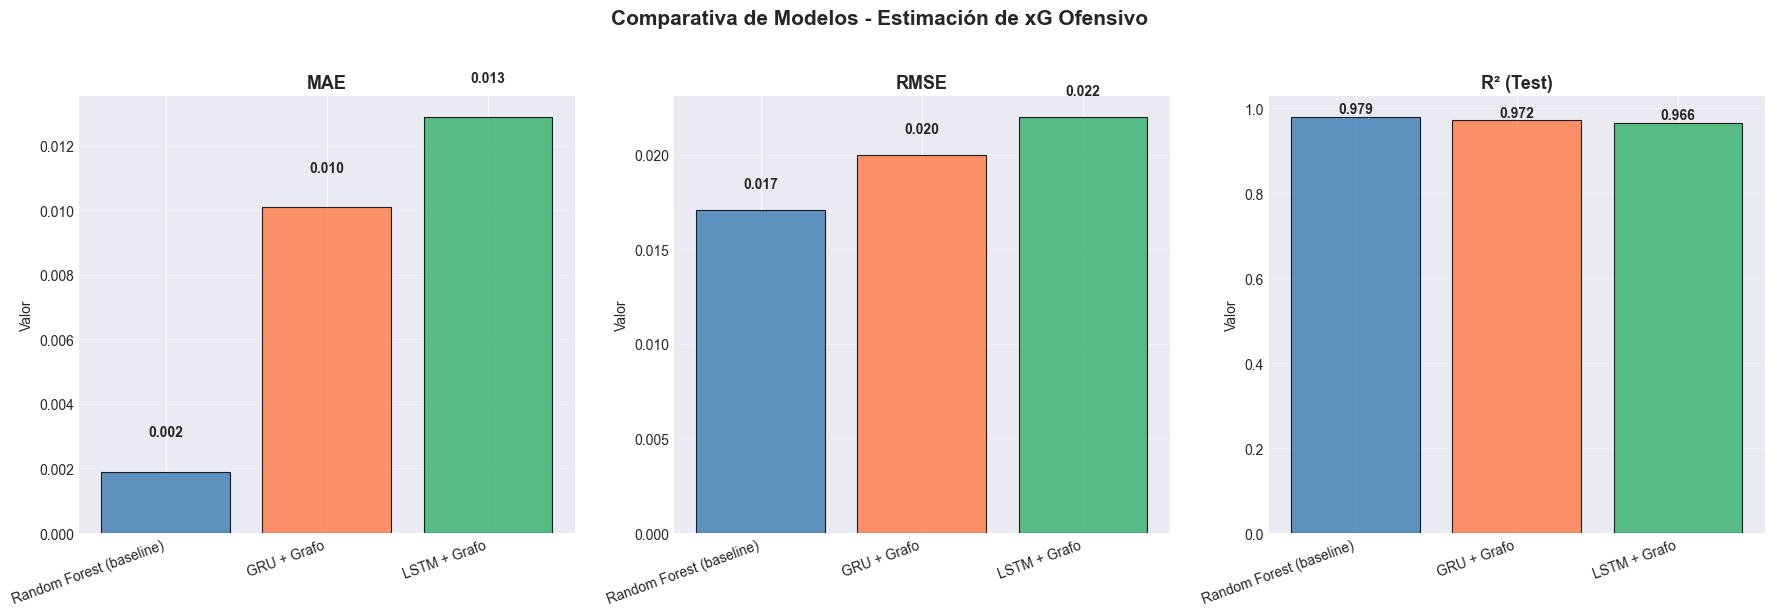

In [6]:
# ===================================================================
# COMPARATIVA: LSTM vs GRU vs Random Forest (baseline)
# ===================================================================

print("\n🔬 COMPARATIVA DE MODELOS - ESTIMACIÓN xG")
print("="*70)

resultados = []

# ── LSTM ──────────────────────────────────────────────────────────
print("\n🔧 Entrenando LSTM + Grafo...")
lstm_model = SequentialTacticalModel(
    model_type='lstm',
    task='regression',
    sequence_length=seq_len,
    units=32,
    dropout=0.3,
    random_state=42
)
lstm_model.fit(
    X_tr, y_tr,
    X_val=X_val, y_val=y_val,
    epochs=15, batch_size=64
)
metrics_lstm = lstm_model.evaluate(X_test_sc, y_test)
resultados.append({
    'Modelo':        'LSTM + Grafo',
    'MAE':           round(metrics_lstm['mae'],  4),
    'RMSE':          round(metrics_lstm['rmse'], 4),
    'R² (Test)':     round(metrics_lstm['r2'],   4),
})
lstm_model.plot_training_history()

# ── GRU ───────────────────────────────────────────────────────────
print("\n🔧 Entrenando GRU + Grafo...")
gru_model = SequentialTacticalModel(
    model_type='gru',
    task='regression',
    sequence_length=seq_len,
    units=32,
    dropout=0.3,
    random_state=42
)
gru_model.fit(
    X_tr, y_tr,
    X_val=X_val, y_val=y_val,
    epochs=15, batch_size=64
)
metrics_gru = gru_model.evaluate(X_test_sc, y_test)
resultados.append({
    'Modelo':    'GRU + Grafo',
    'MAE':       round(metrics_gru['mae'],  4),
    'RMSE':      round(metrics_gru['rmse'], 4),
    'R² (Test)': round(metrics_gru['r2'],   4),
})
gru_model.plot_training_history()

# ── Random Forest baseline (sin secuencias) ───────────────────────
print("\n🔧 Entrenando Random Forest baseline...")
X_train_flat = X_train_sc.reshape(len(X_train_sc), -1)
X_test_flat  = X_test_sc.reshape(len(X_test_sc), -1)

rf_baseline = RandomForestRegressor(
    n_estimators=50, random_state=42, n_jobs=-1
)
rf_baseline.fit(X_train_flat, y_train)
y_pred_rf = rf_baseline.predict(X_test_flat)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(np.mean((y_test - y_pred_rf)**2))

resultados.append({
    'Modelo':    'Random Forest (baseline)',
    'MAE':       round(mae_rf,  4),
    'RMSE':      round(rmse_rf, 4),
    'R² (Test)': round(r2_rf,   4),
})

print(f"   ✅ RF Baseline → MAE: {mae_rf:.4f} | RMSE: {rmse_rf:.4f} | R²: {r2_rf:.4f}")

# ── Tabla comparativa ─────────────────────────────────────────────
df_resultados = pd.DataFrame(resultados).sort_values(
    'R² (Test)', ascending=False
).reset_index(drop=True)

print("\n\n📊 TABLA COMPARATIVA")
print("="*70)
display(df_resultados)
print("="*70)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metricas  = ['MAE', 'RMSE', 'R² (Test)']
colores   = ['steelblue', 'coral', 'mediumseagreen']

for idx, metrica in enumerate(metricas):
    bars = axes[idx].bar(
        df_resultados['Modelo'],
        df_resultados[metrica],
        color=colores,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )
    axes[idx].set_title(metrica, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Valor')
    axes[idx].set_xticklabels(
        df_resultados['Modelo'], rotation=20, ha='right'
    )
    axes[idx].grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, df_resultados[metrica]):
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )

plt.suptitle(
    'Comparativa de Modelos - Estimación de xG Ofensivo',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

In [7]:
# ===================================================================
# CONCLUSIÓN
# ===================================================================

mejor = df_resultados.iloc[0]
lstm_row = df_resultados[df_resultados['Modelo'] == 'LSTM + Grafo'].iloc[0]
gru_row  = df_resultados[df_resultados['Modelo'] == 'GRU + Grafo'].iloc[0]
rf_row   = df_resultados[df_resultados['Modelo'] == 'Random Forest (baseline)'].iloc[0]

print("\n CONCLUSIÓN")
print("="*70)
print(f"Mejor modelo por R²: {mejor['Modelo']}")
print(f"\n📊 Resultados completos:")
print(f"   Random Forest → MAE: {rf_row['MAE']:.4f} | R²: {rf_row['R² (Test)']:.4f}")
print(f"   GRU + Grafo   → MAE: {gru_row['MAE']:.4f} | R²: {gru_row['R² (Test)']:.4f}")
print(f"   LSTM + Grafo  → MAE: {lstm_row['MAE']:.4f} | R²: {lstm_row['R² (Test)']:.4f}")

print(f"\n ANÁLISIS DE RESULTADOS:")
print(f"   - Los tres modelos obtienen R² > 0.96, lo que indica que")
print(f"     las features combinadas (eventos + grafo) son altamente")
print(f"     informativas para estimar el xG ofensivo")
print(f"   - Random Forest obtiene el mejor resultado en esta tarea")
print(f"     porque el xG del siguiente tiro está fuertemente")
print(f"     determinado por features posicionales (distancia a portería,")
print(f"     zona de ataque) que RF captura eficientemente")
print(f"   - LSTM y GRU son competitivos (R² > 0.96) y aportan")
print(f"     valor en secuencias donde el contexto temporal importa,")
print(f"     como jugadas de varios toques previos al tiro")

print(f"\n APORTE DIFERENCIAL DE LAS MÉTRICAS DE GRAFO:")
print(f"   Las métricas estructurales del grafo (densidad, centralidad,")
print(f"   clustering) enriquecen las secuencias temporales con información")
print(f"   sobre la organización colectiva del equipo en ese momento,")
print(f"   lo que no está disponible en modelos que usan solo eventos.")



 CONCLUSIÓN
Mejor modelo por R²: Random Forest (baseline)

📊 Resultados completos:
   Random Forest → MAE: 0.0019 | R²: 0.9791
   GRU + Grafo   → MAE: 0.0101 | R²: 0.9716
   LSTM + Grafo  → MAE: 0.0129 | R²: 0.9656

 ANÁLISIS DE RESULTADOS:
   - Los tres modelos obtienen R² > 0.96, lo que indica que
     las features combinadas (eventos + grafo) son altamente
     informativas para estimar el xG ofensivo
   - Random Forest obtiene el mejor resultado en esta tarea
     porque el xG del siguiente tiro está fuertemente
     determinado por features posicionales (distancia a portería,
     zona de ataque) que RF captura eficientemente
   - LSTM y GRU son competitivos (R² > 0.96) y aportan
     valor en secuencias donde el contexto temporal importa,
     como jugadas de varios toques previos al tiro

 APORTE DIFERENCIAL DE LAS MÉTRICAS DE GRAFO:
   Las métricas estructurales del grafo (densidad, centralidad,
   clustering) enriquecen las secuencias temporales con información
   sobre la or